# ※ 과제 안내
- 과제 배점: 각 문제당 10점, 총점 100점입니다. 부분 점수는 제공되지 않습니다.  

- 채점 기준:  
    - 출력 결과 일치: 제출한 코드가 제시된 출력 결과와 일치하는 경우에만 정답으로 인정됩니다.  
    - 코드의 다양성 인정: 출력 결과가 동일하다면 다양한 접근 방식을 존중하여 정답으로 인정합니다.

- 제출시, O주차_OOO.ipynb로 제출 바랍니다.

---
# 6주차 과제

In [2]:
import warnings
warnings.filterwarnings('ignore')

---
# Q1. Sunspots 데이터 시각화

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# -------------------------------
# [1] 데이터 준비
# sunspots.csv를 프로젝트 아래 로드합니다.
# 데이터 다운로드 링크: https://www.notion.so/metacodem/8-1cc13fa025c08037b713f2d64021b06b?pvs=4
# -------------------------------
def load_and_prepare_data():
    try:
        df = pd.read_csv("sunspots.csv")
    except Exception:
        import statsmodels.api as sm
        df = sm.datasets.sunspots.load_pandas().data
        df["YEAR"] = df["YEAR"].astype(int)
    return df


In [5]:
# -------------------------------
# [2] 전처리 함수
# -------------------------------
def add_features(df, ma_window=10):
    #이동 평균 컬럼, 전년도 대비 백분윤 변화율, IQR, 10년 단위로 그룹화하기 위한 'Decade' 컬럼 추가
    #decade_avg는 10년 단위의 평균 흑점 개수 입니다.

    df[f"{ma_window}Y_MA"] = df["SUNACTIVITY"].rolling(window=ma_window, min_periods=1).mean()
    df["pct_change"] = df["SUNACTIVITY"].pct_change() * 100
    Q1, Q3 = df["SUNACTIVITY"].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df["is_outlier"] = (df["SUNACTIVITY"] < lower_bound) | (df["SUNACTIVITY"] > upper_bound)
    df["Decade"] = (df["YEAR"] // 10) * 10
    decade_avg = df.groupby("Decade")["SUNACTIVITY"].mean()

    return df, decade_avg

In [6]:
# -------------------------------
# [3] 시각화 함수 (완성)
# -------------------------------
def plot_moving_average(df, ma_window=10, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df['YEAR'], df['SUNACTIVITY'], label='Original Sunspots', alpha=0.6)
    ax.plot(df['YEAR'], df[f'{ma_window}Y_MA'], label=f'{ma_window}-Year Moving Avg', color='orange')
    ax.set_title(f"Sunspot Activity & {ma_window}-Year Moving Average")
    ax.set_xlabel("Year")
    ax.set_ylabel("Sunspot Count")
    ax.legend()
    ax.grid(True)


def plot_outliers(df, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df['YEAR'], df['SUNACTIVITY'], label='Sunactivity', alpha=0.5)
    outliers = df[df['is_outlier']]
    ax.scatter(outliers['YEAR'], outliers['SUNACTIVITY'], color='red', label='Outlier', zorder=5)
    ax.set_title("Outliers Detection (IQR Method)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Sunspot Count")
    ax.legend()
    ax.grid(True)


def plot_percentage_change(df, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df['YEAR'], df['pct_change'], color='green', alpha=0.7, label='Percentage Change')
    ax.set_title("Percentage Change of Sunspot Activity")
    ax.set_xlabel("Year")
    ax.set_ylabel("Change (%)")
    ax.legend()
    ax.grid(True)


def plot_decadal_average(decade_avg, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(decade_avg.index, decade_avg.values, width=8, color='purple', alpha=0.7, label='Decadal Avg')
    ax.set_title("Decadal Average Sunspot Activity")
    ax.set_xlabel("Decade")
    ax.set_ylabel("Average Sunactivity")
    ax.legend()
    ax.grid(True)


In [7]:
# -------------------------------
# [4] 전체 시각화 (완성)
# -------------------------------
def plot_all_sunspot_analysis(df, decade_avg, ma_window=10):
    fig, axs = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle("Sunspot Data Analysis Dashboard", fontsize=16)

    plot_moving_average(df, ma_window, axs[0, 0])
    plot_outliers(df, axs[0, 1])
    plot_percentage_change(df, axs[1, 0])
    plot_decadal_average(decade_avg, axs[1, 1])

    axs[2, 0].axis('off')
    axs[2, 1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


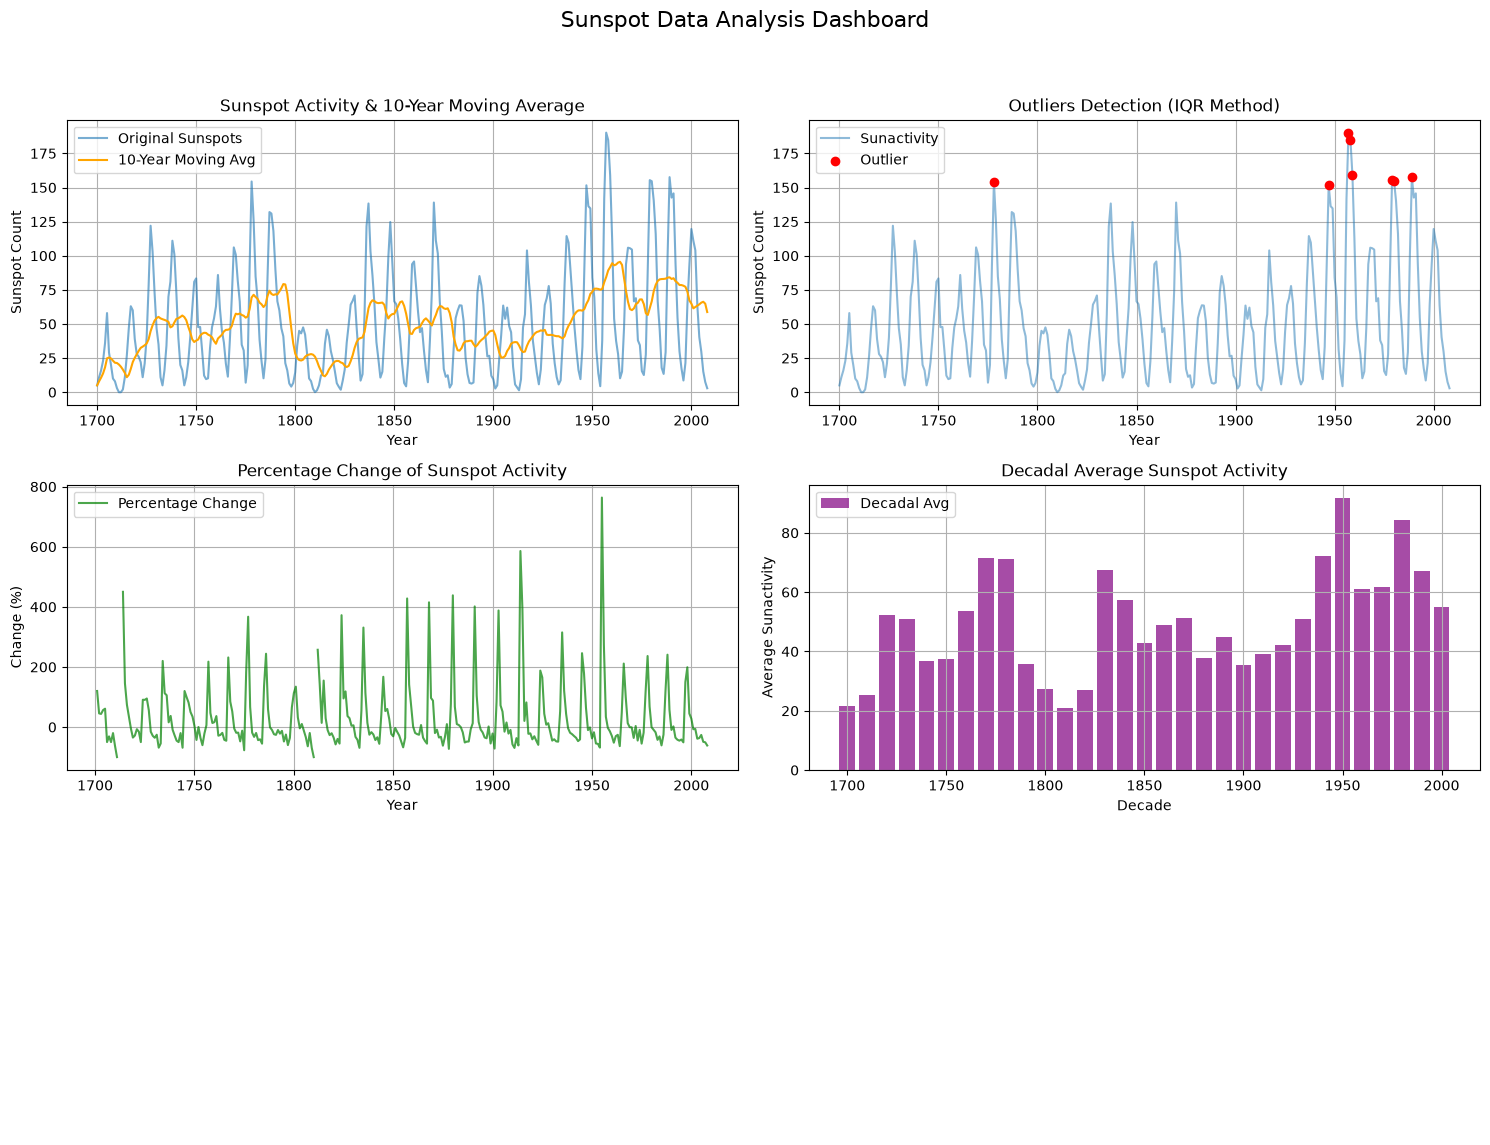

In [9]:
# -------------------------------
# [5] 실행하였을 때 결과물이 같아야 합니다.
# -------------------------------
df = load_and_prepare_data()
df, decade_avg = add_features(df)
plot_all_sunspot_analysis(df, decade_avg, ma_window=10)

---
# Q2. Sunspots 데이터 통계 요약 & Streamlit 배포

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis, gaussian_kde

In [9]:
# --------------------------------------------
# 1) 기본 통계 요약 및 분포 분석
# --------------------------------------------
# 데이터 불러오기 & 전처리
try:
    df = pd.read_csv('data/sunspots.csv')
except Exception:
    try:
        df = pd.read_csv('sunspots.csv')
    except Exception:
        import statsmodels.api as sm
        df = sm.datasets.sunspots.load_pandas().data
df['YEAR'] = df['YEAR'].astype(int)

# 기본 통계 요약 출력
print("기본 통계 요약:")
print(df.describe())

# 왜도와 첨도 계산
data_skew = skew(df['SUNACTIVITY'])
data_kurtosis = kurtosis(df['SUNACTIVITY'])

print("\n데이터 왜도 (Skewness):", data_skew)
print("데이터 첨도 (Kurtosis):", data_kurtosis)


기본 통계 요약:
              YEAR  SUNACTIVITY
count   309.000000   309.000000
mean   1854.000000    49.752104
std      89.344838    40.452595
min    1700.000000     0.000000
25%    1777.000000    16.000000
50%    1854.000000    40.000000
75%    1931.000000    69.800000
max    2008.000000   190.200000

데이터 왜도 (Skewness): 0.9857343925899044
데이터 첨도 (Kurtosis): 0.4110233499827314


In [11]:
# --------------------------------------------
# 2) 결측치 및 이상치 확인
# --------------------------------------------

# 결측치 개수 확인
print("\n결측치 개수:")
print(df.isnull().sum())

# IQR 방법을 사용한 이상치 탐지
Q1 = df['SUNACTIVITY'].quantile(0.25)
Q3 = df['SUNACTIVITY'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\n이상치 탐지를 위한 경계값: 하한 {lower_bound}, 상한 {upper_bound}")

# 이상치 데이터 확인
outliers = df[(df['SUNACTIVITY'] < lower_bound) | (df['SUNACTIVITY'] > upper_bound)]

print("\n탐지된 이상치:")
print(outliers)



결측치 개수:
YEAR           0
SUNACTIVITY    0
dtype: int64

이상치 탐지를 위한 경계값: 하한 -64.69999999999999, 상한 150.5

탐지된 이상치:
     YEAR  SUNACTIVITY
78   1778        154.4
247  1947        151.6
257  1957        190.2
258  1958        184.8
259  1959        159.0
279  1979        155.4
280  1980        154.6
289  1989        157.6


In [12]:
# --------------------------------------------
# 3) 심화 시각화: 다중 서브플롯 구성
# --------------------------------------------
def plot_advanced_sunspot_visualizations(df, sunactivity_col='SUNACTIVITY'):
    """
    태양흑점 데이터의 심화 시각화를 위한 2x2 서브플롯 함수.

    Parameters:
        df: 시계열 데이터프레임 (datetime index 포함)
        sunactivity_col (str): 분석 대상 컬럼명 (기본: 'SUNACTIVITY')
    """
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    # (a) 전체 시계열 라인 차트
    # 전체 시간대(1700년~2000년+) 동안의 흑점 수 추세 시각화
    axs[0, 0].plot(df['YEAR'], df[sunactivity_col], color='blue', alpha=0.7)
    axs[0, 0].set_title("Overall Sunspot Activity Time Series")
    axs[0, 0].set_xlabel("Year")
    axs[0, 0].set_ylabel(sunactivity_col)
    axs[0, 0].grid(True)

    # (b) 분포: 히스토그램 + 커널 밀도
    data = df[sunactivity_col].dropna()
    xs = np.linspace(data.min(), data.max(), 200)
    density = gaussian_kde(data)
    axs[0, 1].hist(data, bins=30, density=True, alpha=0.6, color='gray', label='Histogram')
    axs[0, 1].plot(xs, density(xs), color='red', linewidth=2, label='Density')
    axs[0, 1].set_title("Distribution of Sunspot Activity")
    axs[0, 1].set_xlabel(sunactivity_col)
    axs[0, 1].set_ylabel("Density")
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # (c) 상자 그림: 1900년~2000년
    df_20th = df[(df['YEAR'] >= 1900) & (df['YEAR'] <= 2000)]
    axs[1, 0].boxplot(df_20th[sunactivity_col], vert=False)
    axs[1, 0].set_title("Boxplot of Sunspot Activity (1900-2000)")
    axs[1, 0].set_xlabel(sunactivity_col)

    # (d) 산점도 + 회귀선
    years = df['YEAR']
    sun_activity = df[sunactivity_col]
    axs[1, 1].scatter(years, sun_activity, s=10, alpha=0.5, label='Data Points')
    coef = np.polyfit(years, sun_activity, 1)
    trend = np.poly1d(coef)
    axs[1, 1].plot(years, trend(years), color='red', linewidth=2, label='Trend Line')
    axs[1, 1].set_title("Trend of Sunspot Activity")
    axs[1, 1].set_xlabel("Year")
    axs[1, 1].set_ylabel(sunactivity_col)
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    # 레이아웃 정리
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [13]:
plot_advanced_sunspot_visualizations(df)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_57888\58600821.py:36: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[1, 0].boxplot(df_20th[sunactivity_col], vert=False)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_57888\58600821.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
%%writefile Q2/app.py
# --------------------------------------------
# 4) Streamlit 배포
# sunspots.csv 파일이 에디터 폴더의 data/ 아래에 있어야 합니다.
# --------------------------------------------
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

@st.cache_data
def load_data(file_path):
    df = pd.read_csv(file_path)
    if 'YEAR' in df.columns:
        # 소수점 제거 후 정수로 변환
        df['YEAR_INT'] = df['YEAR'].astype(int)
        df['DATE'] = pd.to_datetime(df['YEAR_INT'].astype(str), format='%Y')
        df.set_index('DATE', inplace=True)
    return df

def plot_advanced_sunspot_visualizations(df, sunactivity_col='SUNACTIVITY'):
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle("Sunspots Data Advanced Visualization", fontsize=18)

    # (a) 전체 시계열 라인 차트
    axs[0, 0].plot(df.index, df[sunactivity_col], color='blue')
    axs[0, 0].set_title("Sunspot Activity Over Time")
    axs[0, 0].set_xlabel("Year")
    axs[0, 0].set_ylabel("Sunspot Count")
    axs[0, 0].grid(True)

    # (b) 분포: 히스토그램 + 커널 밀도
    data = df[sunactivity_col].dropna().values
    if len(data) > 0:  # 데이터가 있는지 확인
        xs = np.linspace(data.min(), data.max(), 200)
        density = gaussian_kde(data)
        axs[0, 1].hist(data, bins=30, density=True, alpha=0.6, color='gray', label='Histogram')
        axs[0, 1].plot(xs, density(xs), color='red', linewidth=2, label='Density')
    axs[0, 1].set_title("Distribution of Sunspot Activity")
    axs[0, 1].set_xlabel("Sunspot Count")
    axs[0, 1].set_ylabel("Density")
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # (c) 상자 그림: 1900년~2000년
    try:
        df_20th = df.loc["1900":"2000"]
        if not df_20th.empty:
            axs[1, 0].boxplot(df_20th[sunactivity_col], vert=False)
    except:
        # 해당 기간 데이터가 없을 경우 예외 처리
        pass
    axs[1, 0].set_title("Boxplot of Sunspot Activity (1900-2000)")
    axs[1, 0].set_xlabel("Sunspot Count")

    # (d) 산점도 + 회귀선
    years = df['YEAR'].values
    sun_activity = df[sunactivity_col].values

    # NaN 값 제거
    mask = ~np.isnan(sun_activity)
    years_clean = years[mask]
    sun_activity_clean = sun_activity[mask]

    if len(years_clean) > 1:  # 회귀선을 그리기 위해 최소 2개 이상의 데이터 필요
        axs[1, 1].scatter(years_clean, sun_activity_clean, s=10, alpha=0.5, label='Data Points')
        coef = np.polyfit(years_clean, sun_activity_clean, 1)
        trend = np.poly1d(coef)
        axs[1, 1].plot(years_clean, trend(years_clean), color='red', linewidth=2, label='Trend Line')
    axs[1, 1].set_title("Trend of Sunspot Activity")
    axs[1, 1].set_xlabel("Year")
    axs[1, 1].set_ylabel("Sunspot Count")
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig

# 메인 앱
st.title('🌞 태양흑점 데이터 분석 대시보드 🌞')
st.markdown("""
    이 대시보드는 태양흑점 데이터를 다양한 시각화 방법으로 보여줍니다.
    """)

try:
    # 데이터 로드
    df = load_data('data/sunspots.csv')

    # 필터링된 데이터 - 전체 데이터 사용
    filtered_df = df

    # 시각화
    if not filtered_df.empty:
        st.subheader('태양흑점 데이터 종합 시각화')
        fig = plot_advanced_sunspot_visualizations(filtered_df)
        st.pyplot(fig)
    else:
        st.warning("데이터가 없습니다.")

except Exception as e:
    st.error(f"오류가 발생했습니다: {e}")
    st.info("데이터 파일의 구조를 확인해주세요. 'data/sunspots.csv' 파일이 존재하고 'YEAR'와 'SUNACTIVITY' 컬럼이 있어야 합니다.")


2026-08-30 21:27:14.030 No runtime found, using MemoryCacheStorageManager
2026-08-30 21:27:14.032 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-30 21:27:14.034 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-30 21:27:14.036 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-30 21:27:14.038 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-30 21:27:14.038 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-30 21:27:14.039 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-30 21:27:14.040 No runtime found, using MemoryCacheStorageManager
2026-08-30 21:27:14.041 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

In [ ]:
'''streamlit 주소를 제출해주세요
주소는 이름+2 로 설정해주세요
'''
#ex https://HongGilDong2.streamlit.app
# 설정 완료한 주소를 제출합니다 :  https://yangkyunghun2.streamlit.app/

'streamlit 주소를 제출해주세요\n주소는 이름+2 로 설정해주세요\n'

In [17]:
# streamlit 배포 결과
from IPython.display import Image, display
image_url = "https://i.imgur.com/Mq93Sgh.png"
display(Image(url=image_url, width=600))

# Q3. Streamlit 시각화 + 인터랙션 추가

In [ ]:
%%writefile app_q3.py
# --------------------------------------------
# Streamlit 시각화 + 인터랙션 추가
# sunspots.csv 파일이 에디터 폴더의 data/ 아래에 있어야 합니다.
# 연도범위, 히스토그램 구간 수, 추세선 차수, 산점도 점 크기, 산점도 투명도를 조절할 수 있는 기능을 추가합니다.
# --------------------------------------------
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

@st.cache_data
def load_data(file_path):
    df = pd.read_csv(file_path)
    if 'YEAR' in df.columns:
        # 소수점 제거 후 정수로 변환
        df['YEAR_INT'] = df['YEAR'].astype(int)
        df['DATE'] = pd.to_datetime(df['YEAR_INT'].astype(str), format='%Y')
        df.set_index('DATE', inplace=True)
    return df

def plot_advanced_sunspot_visualizations(df, sunactivity_col='SUNACTIVITY',
                                        hist_bins=30, trend_degree=1,
                                        point_size=10, point_alpha=0.5):
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle("Sunspots Data Advanced Visualization", fontsize=18)

    # (a) 전체 시계열 라인 차트
    axs[0, 0].plot(df.index, df[sunactivity_col], color='blue')
    axs[0, 0].set_title("Sunspot Activity Over Time")
    axs[0, 0].set_xlabel("Year")
    axs[0, 0].set_ylabel("Sunspot Count")
    axs[0, 0].grid(True)

    # (b) 분포: 히스토그램 + 커널 밀도
    data = df[sunactivity_col].dropna().values
    if len(data) > 0:  # 데이터가 있는지 확인
        xs = np.linspace(data.min(), data.max(), 200)
        density = gaussian_kde(data)

        axs[0, 1].hist(data, bins=hist_bins, density=True, alpha=0.6, color='gray', label='Histogram')

        axs[0, 1].plot(xs, density(xs), color='red', linewidth=2, label='Density')
    axs[0, 1].set_title("Distribution of Sunspot Activity")
    axs[0, 1].set_xlabel("Sunspot Count")
    axs[0, 1].set_ylabel("Density")
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # (c) 상자 그림: 1900년~2000년
    try:
        df_20th = df.loc["1900":"2000"]
        if not df_20th.empty:
            axs[1, 0].boxplot(df_20th[sunactivity_col].dropna(), vert=False)

    except:
        # 해당 기간 데이터가 없을 경우 예외 처리
        pass
    axs[1, 0].set_title("Boxplot of Sunspot Activity (1900-2000)")
    axs[1, 0].set_xlabel("Sunspot Count")

    # (d) 산점도 + 회귀선
    years = df['YEAR'].values
    sun_activity = df[sunactivity_col].values

    # NaN 값 제거
    mask = ~np.isnan(sun_activity)
    years_clean = years[mask]
    sun_activity_clean = sun_activity[mask]

    if len(years_clean) > 1:  # 회귀선을 그리기 위해 최소 2개 이상의 데이터 필요
        axs[1, 1].scatter(years_clean, sun_activity_clean, s=point_size, alpha=point_alpha, label='Data Points')
        coef = np.polyfit(years_clean, sun_activity_clean, trend_degree)
        trend = np.poly1d(coef)

        # 추세선을 그리기 위한 x 값 생성
        x_trend = np.linspace(years_clean.min(), years_clean.max(), 100)
        axs[1, 1].plot(x_trend, trend(x_trend), color='red', linewidth=2, label='Trend Line')
    axs[1, 1].set_title("Trend of Sunspot Activity")
    axs[1, 1].set_xlabel("Year")
    axs[1, 1].set_ylabel("Sunspot Count")
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig

# 메인 앱
st.title('🌞 태양흑점 데이터 분석 대시보드 🌞')
st.markdown("""
    이 대시보드는 태양흑점 데이터를 다양한 시각화 방법으로 보여줍니다.
    """)

try:
    # 데이터 로드
    df = load_data('data/sunspots.csv')

    # 사이드바에 파라미터 조절 슬라이더 추가
    st.sidebar.header('시각화 파라미터 조절')

    # 연도 범위 선택
    min_year = int(df['YEAR_INT'].min())
    max_year = int(df['YEAR_INT'].max())
    year_range = st.sidebar.slider(
        '연도 범위 선택',
        min_value=min_year,
        max_value=max_year,
        value=(min_year, max_year)
    )

    # 히스토그램 빈(bin) 수 조절
    hist_bins = st.sidebar.slider(
        '히스토그램 구간 수',
        min_value=5,
        max_value=100,
        value=30
    )

    # 추세선 차수 조절
    trend_degree = st.sidebar.slider(
        '추세선 차수',
        min_value=1,
        max_value=5,
        value=1
    )

    # 산점도 점 크기 조절
    point_size = st.sidebar.slider(
        '산점도 점 크기',
        min_value=5,
        max_value=50,
        value=10
    )

    # 산점도 투명도 조절
    point_alpha = st.sidebar.slider(
        '산점도 투명도',
        min_value=0.10,
        max_value=1.00,
        value=0.50,
        step=0.05
    )

    # 필터링된 데이터
    filtered_df = df[(df['YEAR_INT'] >= year_range[0]) & (df['YEAR_INT'] <= year_range[1])]

    # 시각화
    if not filtered_df.empty:
        st.subheader('태양흑점 데이터 종합 시각화')
        fig = plot_advanced_sunspot_visualizations(
            filtered_df,
            hist_bins=hist_bins,
            trend_degree=trend_degree,
            point_size=point_size,
            point_alpha=point_alpha
        )
        st.pyplot(fig)
    else:
        st.warning("선택한 기간에 데이터가 없습니다.")

except Exception as e:
    st.error(f"오류가 발생했습니다: {e}")
    st.info("데이터 파일의 구조를 확인해주세요. 'data/sunspots.csv' 파일이 존재하고 'YEAR'와 'SUNACTIVITY' 컬럼이 있어야 합니다.")


In [ ]:
'''streamlit 주소를 제출해주세요
주소는 이름+3 로 설정해주세요
'''
#ex https://HongGilDong3.streamlit.app
# 설정 완료한 주소를 제출합니다 : https://yangkyunghun3.streamlit.app/


In [ ]:
# streamlit 배포 결과
from IPython.display import Image, display
image_url = "https://i.imgur.com/lVpB5AP.png"
display(Image(url=image_url, width=600))

---
# Q4. Prophet 모델 학습

In [23]:
'''
[1] 데이터 준비 및 전처리
data는 위에서 제공해드린 코드로 sunspots를 사용하고자 합니다.
현재 모델 학습을 위해서 다음과 같은 전처리를 하고자 합니다.
# - 'date'와 'SUNACTIVITY' 컬럼만 추출, 데이터 변환
# - 1900년 이후(1900-01-01 ~ 2008-01-01) datetime 데이터로 제한, %Y-%m-%d의 형태

이 두가지를 거쳐서 학습을 하고자 합니다.

Q1~Q2로부터 나온 df를 그대로 사용합니다.
'''

processed_df = (
    df[(df['YEAR'] >= 1900) & (df['YEAR'] <= 2008)]
    .assign(ds=lambda x: pd.to_datetime(x['YEAR'].astype(int).astype(str), format='%Y'))
    [['ds', 'SUNACTIVITY']]
    .rename(columns={'SUNACTIVITY': 'y'})
    .reset_index(drop=True)
)
print("데이터 미리보기:")
print(processed_df.head())

데이터 미리보기:
          ds     y
0 1900-01-01   9.5
1 1901-01-01   2.7
2 1902-01-01   5.0
3 1903-01-01  24.4
4 1904-01-01  42.0


In [24]:
# [2] 모델 학습
# - 기본 yearly_seasonality를 비활성화하고, changepoint_prior_scale 등 파라미터 튜닝
# - Sunspot 데이터의 주기성(약 11년)을 반영하는 커스텀 시즌얼리티 추가
from prophet import Prophet

model = Prophet(
    yearly_seasonality=False,  # 기본 연간 시즌얼리티 비활성화
    changepoint_prior_scale=0.05,
    seasonality_mode='additive'
)
# 약 11년 주기의 태양 흑점 사이클을 커스텀 시즌얼리티로 추가 (fourier_order는 데이터에 따라 조정)
model.add_seasonality(name='sunspot_cycle', period=11, fourier_order=5)
# 모델 학습
model.fit(processed_df)

21:42:24 - cmdstanpy - INFO - Chain [1] start processing
21:42:24 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
# [3] 예측
# - 50년 뒤까지 예측하기 위한 future DataFrame 생성 (연 단위)
future = model.make_future_dataframe(periods=50, freq='YE')
forecast = model.predict(future)
print("\nForecast 상위 5행:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())


Forecast 상위 5행:
          ds       yhat  yhat_lower  yhat_upper
0 1900-01-01  40.942188  -19.478951   95.620420
1 1901-01-01  48.494635   -4.896769  102.351567
2 1902-01-01  54.951294   -7.743638  112.871938
3 1903-01-01  60.445078    2.406521  118.892174
4 1904-01-01  53.613382   -4.173922  113.468888


In [26]:
# [4] 모델 진단: 교차 검증 및 성능 평가 (선택 사항)
# Prophet의 교차 검증 기능을 사용하여 예측 성능을 평가합니다.
# 데이터 기간이 1900~2008년이므로, 초기 학습 기간은 80년, horizon은 10년, period는 5년으로 설정합니다.
from prophet.diagnostics import cross_validation, performance_metrics

print("\n교차 검증 시작...")
cv_results = cross_validation(model, initial='29200 days', period='1825 days', horizon='3650 days')
perf_metrics = performance_metrics(cv_results)
print("\nPerformance Metrics 상위 5행:")
print(perf_metrics.head())

# [5] 예측 결과 시각화 (예측 구성요소 플롯)
fig1 = model.plot(forecast)
plt.title("Forecast Plot")
plt.xlabel("Year")
plt.ylabel("Sunspot Activity")
plt.show()

fig2 = model.plot_components(forecast)
plt.suptitle("Forecast Components", fontsize=16)
plt.show()


교차 검증 시작...


  0%|          | 0/4 [00:00<?, ?it/s]21:42:29 - cmdstanpy - INFO - Chain [1] start processing
21:42:29 - cmdstanpy - INFO - Chain [1] done processing
 25%|██▌       | 1/4 [00:00<00:01,  2.92it/s]21:42:29 - cmdstanpy - INFO - Chain [1] start processing
21:42:29 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 2/4 [00:00<00:00,  2.95it/s]21:42:29 - cmdstanpy - INFO - Chain [1] start processing
21:42:29 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████▌  | 3/4 [00:00<00:00,  3.22it/s]21:42:30 - cmdstanpy - INFO - Chain [1] start processing
21:42:30 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 4/4 [00:01<00:00,  2.99it/s]
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_57888\2396692580.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()



Performance Metrics 상위 5행:
   horizon          mse       rmse        mae      mape     mdape     smape  \
0 363 days  3298.984216  57.436785  51.026703  1.021075  0.793221  0.624521   
1 725 days  4622.838223  67.991457  60.415929  1.986261  1.437259  0.801225   
2 726 days  4056.031068  63.686977  55.953980  1.967059  1.398854  0.770390   
3 727 days  4556.198841  67.499621  59.136898  2.576718  2.618172  0.850986   
4 728 days  4828.081099  69.484395  65.669905  2.626780  2.618172  0.911832   

   coverage  
0      0.50  
1      0.25  
2      0.50  
3      0.50  
4      0.50  


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_57888\2396692580.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
# Q5. Prophet 예측 결과 시각화 & Stremlit 배포

In [ ]:
# --------------------------------------------------
# [1] Prophet 기본 시각화
# --------------------------------------------------
# TODO 1: Prophet 모델의 기본 시각화 도구를 사용해 예측 결과를 시각화하세요.
# Prophet 모델이 제공하는 기본 플롯 함수로 예측 결과와 구성요소를 시각화합니다.
fig1 = model.plot(forecast)
plt.title("Forecast Plot")
plt.xlabel("Year")
plt.ylabel("Sunspot Activity")
# plt.show()

fig2 = model.plot_components(forecast)
plt.suptitle("Forecast Components", fontsize=16)
# plt.show()


In [ ]:
# --------------------------------------------------
# [2] 실제 값과 예측 값 비교: 커스텀 시각화 (라인 차트 + 신뢰구간)
# --------------------------------------------------
# TODO 2: 실제값, 예측값, 신뢰구간을 하나의 plot에 함께 시각화하세요.

plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)

plt.plot(processed_df["ds"], processed_df["y"], label="Actual Data", color="black", alpha=0.7)
plt.plot(forecast["ds"], forecast["yhat"], label="Forecast (yhat)", color="blue", linewidth=2)
plt.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"], color="blue", alpha=0.2, label="Uncertainty Interval")

plt.title("Sunspots: Actual vs. Predicted with Prediction Intervals")
plt.xlabel("Year")
plt.ylabel("Sun Activity")
plt.legend()
plt.grid(True)


In [ ]:
# --------------------------------------------------
# [3] 잔차(Residual) 분석: 예측값과 실제값의 차이 시각화
# --------------------------------------------------
# TODO 3: df와 forecast를 날짜 기준으로 병합하고, 잔차를 계산한 뒤 시각화하세요.

# 3-1. df의 인덱스를 초기화하고, 날짜 컬럼명을 Prophet 형식(ds)으로 변경
df_ds = processed_df.copy()

# 3-2. forecast와 병합 (inner join) 후 residual 컬럼 생성
merged_df = pd.merge(df_ds, forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='inner')
merged_df['residual'] = merged_df['y'] - merged_df['yhat']

# 3-3. 잔차 시각화
plt.subplot(2, 1, 2)

plt.plot(merged_df['ds'], merged_df['residual'], color='red', alpha=0.7, label='Residual (Actual - Predicted)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title("Residual Analysis (Actual - Predicted)")
plt.xlabel("Year")
plt.ylabel("Residual")
plt.legend()
plt.grid(True)

plt.tight_layout()
# plt.show()


In [ ]:
# 원본 데이터 로드

import statsmodels.api as sm
df = sm.datasets.sunspots.load_pandas().data
df["YEAR"] = df["YEAR"].astype(int)
df["date"] = pd.to_datetime(df["YEAR"], format="%Y")
df = df.set_index("date").sort_index()

# Prophet용 전처리
# 1. 인덱스를 다시 컬럼으로 변환(reset_index)
# 2. Prophet은 입력 컬럼명으로 'ds'(날짜)와 'y'(타겟값)를 요구하므로 컬럼명 변경
processed_df = df.reset_index()[['date', 'SUNACTIVITY']].rename(columns={'date': 'ds', 'SUNACTIVITY': 'y'})

# 1900-01-01부터 2008-01-01까지의 데이터만 필터링
# Prophet 모델 학습에 사용할 기간을 제한함
processed_df = processed_df[(processed_df['ds'] >= '1900-01-01') & (processed_df['ds'] <= '2008-01-01')].reset_index(drop=True)

# 전처리된 데이터프레임을 CSV 파일(경로: ./sunspots_for_prophet.csv)로 저장
# index=False 옵션은 데이터프레임의 인덱스를 CSV에 포함시키지 않음
# 저장한 파일도 같이 제출해주세요.
processed_df.to_csv('./sunspots_for_prophet.csv', index=False)

print("✅ prophet용 데이터 저장 완료!")


In [ ]:
%%writefile Q5/app.py
# --------------------------------------------------
# [4] 시각화한 내용을 Steamlit에 배포하세요.
# 위에서 생성한 sunspots_for_prophet.csv를 다운로드 받아, 루트/data 아래에 넣어주세요.
# --------------------------------------------------
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# 페이지 설정
st.set_page_config(page_title="🌞 Sunspot Forecast", layout="wide")
st.title("🌞 Prophet Forecast with Preprocessed Sunspot Data")

# ----------------------------------
# [1] 데이터 불러오기
# ----------------------------------
# TODO: 'sunspots_for_prophet.csv' 파일을 불러오고, 'ds' 컬럼을 datetime 형식으로 변환하세요.
try:
    df = pd.read_csv("sunspots_for_prophet.csv")
except Exception:
    df = pd.read_csv("data/sunspots.csv")
    df['YEAR'] = df['YEAR'].astype(int)
    df = df[(df['YEAR'] >= 1900) & (df['YEAR'] <= 2008)]
    df['ds'] = pd.to_datetime(df['YEAR'].astype(str), format='%Y')
    df = df[['ds', 'SUNACTIVITY']].rename(columns={'SUNACTIVITY': 'y'})

df['ds'] = pd.to_datetime(df['ds'])

st.subheader("📄 데이터 미리보기")
st.write(df.head())

# ----------------------------------
# [2] Prophet 모델 정의 및 학습
# ----------------------------------
# TODO: Prophet 모델을 생성하고, 11년 주기 커스텀 seasonality를 추가한 후 학습하세요.
m = Prophet(yearly_seasonality=False, changepoint_prior_scale=0.05)
m.add_seasonality(name='sunspot_cycle', period=11, fourier_order=5)
m.fit(df)

# ----------------------------------
# [3] 예측 수행
# ----------------------------------
# TODO: 30년간 연 단위 예측을 수행하고, 결과를 forecast에 저장하세요.
try:
    future = m.make_future_dataframe(periods=30, freq='YE')
except Exception:
    future = m.make_future_dataframe(periods=30, freq='Y')
forecast = m.predict(future)

# ----------------------------------
# [4] 기본 시각화
# ----------------------------------
st.subheader("📈 Prophet Forecast Plot")
# TODO: model.plot()을 사용하여 예측 결과를 시각화하세요.
fig1 = m.plot(forecast)
st.pyplot(fig1)

st.subheader("📊 Forecast Components")
# TODO: model.plot_components()를 사용하여 구성요소를 시각화하세요.
fig2 = m.plot_components(forecast)
st.pyplot(fig2)

# ----------------------------------
# [5] 커스텀 시각화: 실제값 vs 예측값 + 신뢰구간
# ----------------------------------
st.subheader("📉 Custom Plot: Actual vs Predicted with Prediction Intervals")

# TODO: 실제값, 예측값, 신뢰구간을 하나의 plot에 시각화하세요.
fig3, ax = plt.subplots(figsize=(14, 6))

ax.plot(df["ds"], df["y"], label="Actual Data", color="black", alpha=0.7)
ax.plot(forecast["ds"], forecast["yhat"], label="Forecast (yhat)", color="blue", linewidth=2)
ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"], color="blue", alpha=0.2, label="Uncertainty Interval")
ax.set_title("Sunspot Activity Forecast with Prophet")
ax.set_xlabel("Year")
ax.set_ylabel("Sunspot Count")
ax.legend()
ax.grid(True)

st.pyplot(fig3)

# ----------------------------------
# [6] 잔차 분석 시각화
# ----------------------------------
st.subheader("📉 Residual Analysis (예측 오차 분석)")

# TODO: df와 forecast를 'ds' 기준으로 병합하여 residual 컬럼을 생성하세요.
merged = pd.merge(df, forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='inner')
merged['residual'] = merged['y'] - merged['yhat']

# TODO: residual 시계열을 시각화하세요.
fig4, ax2 = plt.subplots(figsize=(14, 4))

ax2.plot(merged["ds"], merged["residual"], color="red", alpha=0.7, label="Residual (y - yhat)")
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("Forecast Residuals")
ax2.set_xlabel("Year")
ax2.set_ylabel("Residual")
ax2.legend()
ax2.grid(True)

st.pyplot(fig4)

# ----------------------------------
# [7] 잔차 통계 요약 출력
# ----------------------------------
st.subheader("📌 Residual Summary Statistics")
# TODO: merged["residual"].describe()를 출력하세요.
st.write(merged["residual"].describe())


In [ ]:
'''streamlit 주소를 제출해주세요
주소는 이름+5 로 설정해주세요
'''
#ex https://HongGilDong5.streamlit.app
# 설정 완료한 주소를 제출합니다 : https://yangkyunghun5.streamlit.app/


In [ ]:
# streamlit 배포 결과
from IPython.display import Image, display
image_url = "https://i.imgur.com/b3e0XU7.png"
display(Image(url=image_url, width=600))

# Q6. 머신러닝 실습 1

In [ ]:
'''
# 채무불이행 데이터로 예측 모델을 학습시키고, 베스트 모델과 accuracy를 뽑아냅니다.
# test.csv, train.csv를 루트 폴더 아래 업로드합니다.
# 파일 다운로드 링크: https://www.notion.so/metacodem/8-1cc13fa025c08037b713f2d64021b06b

'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 로드
'''코드를 작성하시오'''



In [ ]:
# 2. 데이터 탐색 및 기본 분석
'''코드를 작성하시오'''


Train 데이터 크기: (10000, 18)
Test 데이터 크기: (2062, 17)


In [ ]:
# 3. 데이터 전처리 함수 정의
def preprocess_data(X, y, test_size=0.2, random_state=42):
    """
    데이터 분할 및 스케일링을 수행하는 함수

    Parameters:
        X, y: 특성 및 타겟 데이터
        test_size: 테스트 데이터 비율
        random_state: 시드 값

    Returns:
        X_train_scaled, X_test_scaled, y_train, y_test, scaler
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


In [ ]:
# 4. 모델 학습 및 평가를 위한 함수
def train_and_evaluate(models, X_train, X_test, y_train, y_test):
    """
    여러 모델을 학습하고 평가하는 함수

    Parameters:
        models: dict, {모델_이름: 모델_객체}
        X_train, X_test, y_train, y_test: 학습 및 테스트 데이터

    Returns:
        results: dict, 모델별 평가 지표
        fitted_models: dict, 학습된 모델 객체
    """
    results = {}
    fitted_models = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results[name] = {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        }
        fitted_models[name] = model

    return results, fitted_models


In [ ]:
# 5. 메인 실행 코드
# 1) 데이터 전처리
X_train_scaled, X_test_scaled, y_train, y_test, scaler = preprocess_data(X, y)

# 2) 비교할 회귀 모델 정의
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# 3) 모델 학습 및 평가
results, fitted_models = train_and_evaluate(models, X_train_scaled, X_test_scaled, y_train, y_test)

# 결과 출력
results_df = pd.DataFrame(results).T
print("=== 모델별 성능 평가 ===")
print(results_df)


In [ ]:
  # 출력
  EPOCHS = 100

  print("\n학습 시작...")
  final_model, final_model_name, final_accuracy = main(epochs=EPOCHS)
  print("\n학습 완료! 최종 정확도: {:.4f}".format(final_accuracy))


학습 시작...

채무 불이행 예측 모델 개발 시작

전처리 후 특성 개수: 23
학습 데이터 크기: 8000 샘플
검증 데이터 크기: 2000 샘플

=== 로지스틱 회귀 ===

로지스틱 회귀 성능:
정확도: 0.7050
ROC AUC: 0.7245
              precision    recall  f1-score   support

           0       0.73      0.89      0.80      1318
           1       0.62      0.35      0.45       682

    accuracy                           0.70      2000
   macro avg       0.67      0.62      0.62      2000
weighted avg       0.69      0.70      0.68      2000


=== 랜덤 포레스트 ===

랜덤 포레스트 성능:
정확도: 0.7260
ROC AUC: 0.7278
              precision    recall  f1-score   support

           0       0.74      0.91      0.81      1318
           1       0.68      0.38      0.48       682

    accuracy                           0.73      2000
   macro avg       0.71      0.64      0.65      2000
weighted avg       0.72      0.73      0.70      2000


=== 그래디언트 부스팅 ===

그래디언트 부스팅 성능:
정확도: 0.7315
ROC AUC: 0.7517
              precision    recall  f1-score   support

           0       0.75     

---
# Q7. 머신러닝 실습 2




In [ ]:
'''
# 유방암 진단 분류 모델을 학습시켜 accuracy 0.97 이상을 달성해주세요.
'''
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings

'''코드 추가'''
warnings.filterwarnings('ignore')

# 목표 정확도 설정
TARGET_ACCURACY = 0.97

# 데이터 로드
print("=== 유방암 진단 분류 모델 개발 ===")
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

# 데이터셋 기본 정보 출력
print(f"데이터셋 크기: {X.shape}")
print(f"클래스 분포: {np.bincount(y)} (0: 악성, 1: 양성)")

# 데이터 전처리
# 1. 추가 특성 생성
def create_features(X):
    df = X.copy()

    # 평균-최악 특성 간 차이 및 비율 계산
    for base in ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness']:
        mean_col = f'mean {base}'
        worst_col = f'worst {base}'
        if mean_col in df.columns and worst_col in df.columns:
            df[f'{base}_diff'] = df[worst_col] - df[mean_col]
            df[f'{base}_ratio'] = df[worst_col] / (df[mean_col] + 1e-8)

    return df

# 특성 엔지니어링 적용
X_processed = create_features(X)
print(f"특성 엔지니어링 후 특성 개수: {X_processed.shape[1]}")

=== 유방암 진단 분류 모델 개발 ===
데이터셋 크기: (569, 30)
클래스 분포: [212 357] (0: 악성, 1: 양성)
특성 엔지니어링 후 특성 개수: 42


In [ ]:
# 2. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


학습 데이터 크기: (455, 42)
테스트 데이터 크기: (114, 42)


In [ ]:
# 3. 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# 4. 모델 학습
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)



=== 모델 학습 ===
모델 학습 완료


In [ ]:
# 예측 및 평가
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

# 분류 보고서 출력
print("\n=== 모델 성능 평가 ===")
print(f"정확도: {accuracy:.4f}")
print("\n분류 보고서:")
print(classification_report(y_test, y_pred, target_names=['악성', '양성']))

# 중요 특성 출력
feature_importances = pd.DataFrame({
    'feature': X_processed.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== 중요 특성 (상위 10개) ===")
print(feature_importances.head(10))

# 목표 정확도 달성 여부 확인
print("\n=== 목표 정확도 평가 ===")
if accuracy >= TARGET_ACCURACY:
    print(f"✅ 목표 정확도({TARGET_ACCURACY:.4f})를 달성했습니다! 모델 정확도: {accuracy:.4f}")
else:
    print(f"❌ 목표 정확도({TARGET_ACCURACY:.4f})에 도달하지 못했습니다. 모델 정확도: {accuracy:.4f}")
    print(f"목표까지 남은 차이: {(TARGET_ACCURACY - accuracy):.4f}")


=== 모델 성능 평가 ===
정확도: 0.9737

분류 보고서:
              precision    recall  f1-score   support

          악성       0.98      0.95      0.96        42
          양성       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


=== 중요 특성 (상위 10개) ===
                 feature  importance
36             area_diff    0.142677
22       worst perimeter    0.105833
20          worst radius    0.095978
27  worst concave points    0.090752
7    mean concave points    0.086974
30           radius_diff    0.081744
23            worst area    0.059723
34        perimeter_diff    0.048864
0            mean radius    0.033319
31          radius_ratio    0.028633

=== 목표 정확도 평가 ===
✅ 목표 정확도(0.9700)를 달성했습니다! 모델 정확도: 0.9737


---
# Q8. Tensor 다루기

In [ ]:
##########################################
# PyTorch Tensor 생성 및 기본 조작
##########################################
import torch

# 1. 0~1 난수 (3, 4)
rand_tensor = torch.rand(3, 4)

# 2. 정규분포 난수 (3, 4)
randn_tensor = torch.randn(3, 4)

# 3. [1, 10) 정수 난수 (3, 4)
randint_tensor = torch.randint(1, 10, (3, 4))

# 4. 1차원 flatten
flat_tensor = randint_tensor.view(-1)

# 5. shape (4, 3)으로 reshape
reshaped_tensor = flat_tensor.reshape(4, 3)

# 6. 각 행의 합(dim=1) 및 각 열의 평균(dim=0)
row_sum = reshaped_tensor.sum(dim=1)
col_mean = reshaped_tensor.float().mean(dim=0)

print("1. Rand Tensor:\n", rand_tensor)
print("\n2. Randn Tensor:\n", randn_tensor)
print("\n3. Randint Tensor:\n", randint_tensor)
print("\n4. Flattened Tensor:\n", flat_tensor)
print("\n5. Reshaped Tensor (4, 3):\n", reshaped_tensor)
print("\n6. Row Sums:\n", row_sum)
print("6. Column Means:\n", col_mean)


=== Tensor a ===
tensor([[1, 2],
        [3, 4]])
=== Tensor b ===
tensor([[5, 6],
        [7, 8]])
=== Tensor c (for broadcasting) ===
tensor([[10],
        [20]])

--- Element-wise Operations ---
a + b = tensor([[ 6,  8],
        [10, 12]])
a - b = tensor([[-4, -4],
        [-4, -4]])
a * b = tensor([[ 5, 12],
        [21, 32]])
a / b = tensor([[0.2000, 0.3333],
        [0.4286, 0.5000]])

--- Broadcasting Operation ---
a + c = tensor([[11, 12],
        [23, 24]])

=== 3D Tensor ===
tensor([[[82, 30, 48, 52, 26],
         [92,  8, 39, 42, 27],
         [19, 23, 23, 94, 92],
         [44, 15, 26, 25, 89]],

        [[39, 21, 17, 37, 99],
         [60, 68, 89, 72, 52],
         [54, 87, 68,  1, 62],
         [28, 29,  7, 68, 50]],

        [[67, 66, 87, 45, 99],
         [12, 86, 51, 92, 24],
         [39, 97, 57, 76, 14],
         [ 2, 16, 82, 32, 17]]])
Tensor shape: torch.Size([3, 4, 5])

--- Global Aggregations on 3D Tensor ---
Global minimum: tensor(1)
Global maximum: tensor(99)
G

In [ ]:
##########################################
# Tensor 연산 및 브로드캐스팅
##########################################
# 1. Shape (2, 3) 텐서 A, B
A = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
B = torch.tensor([[0.5, 1.5, 2.5], [3.5, 4.5, 5.5]])

# 2. Element-wise 곱
elementwise_mult = A * B

# 3. 행렬 곱 (A x B.T)
matmul_result = torch.matmul(A, B.T)

# 4. 브로드캐스팅: (2, 3) + (1, 3)
C = torch.tensor([[10.0, 20.0, 30.0]])
broadcast_add = A + C

# 5. 마스킹 및 조건검색 (A > 3.0)
mask = A > 3.0
filtered_elements = A[mask]

print("A:\n", A)
print("B:\n", B)
print("\nElement-wise Multiplication:\n", elementwise_mult)
print("\nMatrix Multiplication (A @ B.T):\n", matmul_result)
print("\nBroadcasting (A + C):\n", broadcast_add)
print("\nFiltered Elements (A > 3.0):\n", filtered_elements)


=== 텐서 a ===
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
a.shape: torch.Size([3, 3])
a의 2행 3열(인덱스로는 1,2) 원소: tensor(6)
a의 첫 2행, 마지막 2열 슬라이싱 결과:
tensor([[2, 3],
        [5, 6]])
a의 마지막 행 전체 추출 (음수 인덱싱):
tensor([7, 8, 9])
a에서 5보다 큰 원소들 (불리언 인덱싱):
tensor([6, 7, 8, 9])
a에서 행 인덱스 [0, 2]와 열 인덱스 [1, 2]의 원소:
tensor([[2, 3],
        [8, 9]])

=== 텐서 b ===
tensor([[[0.5140, 0.4483, 0.2065],
         [0.5545, 0.9869, 0.5795],
         [0.1914, 0.6109, 0.5503]],

        [[0.8107, 0.5059, 0.7827],
         [0.5845, 0.0691, 0.6798],
         [0.7881, 0.1461, 0.6923]],

        [[0.0348, 0.0671, 0.9528],
         [0.9974, 0.9638, 0.0789],
         [0.1386, 0.4960, 0.2568]]])
b.shape: torch.Size([3, 3, 3])
b의 (0,0,2) 위치 원소: tensor(0.2065)
b[..., 1] (마지막 차원에서 인덱스 1 선택):
tensor([[0.4483, 0.9869, 0.6109],
        [0.5059, 0.0691, 0.1461],
        [0.0671, 0.9638, 0.4960]])
b에서 고급 인덱싱으로 선택한 원소들 (각 차원별 지정된 인덱스):
tensor([0.5795, 0.7881, 0.0671])
b에서 0.5보다 큰 원소들 (불리언 인덱싱):
tensor([0.5140, 0.55

In [ ]:
##########################################
# 인덱싱, 슬라이싱 및 장치(Device) 설정
##########################################
# 1. Shape (4, 4) 텐서 생성
matrix = torch.tensor([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
], dtype=torch.float32)

# 2. 대각선 원소 추출
diag_elements = torch.diag(matrix)

# 3. 중앙 2x2 서브 행렬
sub_matrix = matrix[1:3, 1:3]

# 4. 조건 변경 (> 10 -> -1.0)
matrix_modified = matrix.clone()
matrix_modified[matrix_modified > 10] = -1.0

# 5. Device 설정 및 이동
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
matrix_on_device = matrix.to(device)

print("Matrix:\n", matrix)
print("\nDiagonal Elements:\n", diag_elements)
print("\nCenter 2x2 Sub-matrix:\n", sub_matrix)
print("\nModified Matrix (>10 -> -1):\n", matrix_modified)
print(f"\nDevice: {device}, Tensor Device: {matrix_on_device.device}")


===== Advanced Shaping Operations Challenge =====

원본 텐서 a:
tensor([[1, 2, 3, 4],
        [5, 6, 7, 8]])
a.shape: torch.Size([2, 4])

Reshaped a into [2,2,2]:
tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])
reshaped_a.shape: torch.Size([2, 2, 2])

Permuted reshaped a (swap dim0 and dim2):
tensor([[[1, 5],
         [3, 7]],

        [[2, 6],
         [4, 8]]])
perm_a.shape: torch.Size([2, 2, 2])

Reshaped a into [1, -1, 4]:
tensor([[[1, 2, 3, 4],
         [5, 6, 7, 8]]])
reshaped_a2.shape: torch.Size([1, 2, 4])

Squeezed a2 (제거 후):
tensor([[1, 2, 3, 4],
        [5, 6, 7, 8]])
squeezed_a2.shape: torch.Size([2, 4])

원본 텐서 b:
tensor([[[[[0.4042, 0.9985, 0.4592, 0.8433, 0.3796, 0.0943]],

          [[0.9294, 0.9640, 0.9471, 0.7796, 0.7384, 0.7316]],

          [[0.7200, 0.6013, 0.4347, 0.4096, 0.6373, 0.2346]],

          [[0.6980, 0.4935, 0.5232, 0.4254, 0.3838, 0.8241]]]],



        [[[[0.6065, 0.1726, 0.0433, 0.1837, 0.3913, 0.5588]],

          [[0.2896, 0.3683,

---
# Q9. Matrix Multiplication & Linear Layer

In [ ]:
import torch

# 1. 커스텀 선형 레이어 구현 (PyTorch nn.Linear 미사용)
class CustomLinear:
    def __init__(self, in_features, out_features):
        self.weight = torch.randn(in_features, out_features, requires_grad=True)
        self.bias = torch.zeros(out_features, requires_grad=True)

    def forward(self, x):
        return torch.matmul(x, self.weight) + self.bias


=== Batched Matrix Multiplication ===
m1.shape: torch.Size([2, 3, 4])
m2.shape: torch.Size([2, 4, 5])
Batched multiplication result shape: torch.Size([2, 3, 5])
tensor([[[ 0.0511, -4.8630,  2.0746, -0.2180, -1.4106],
         [-0.2876, -8.5133,  0.5865, -1.3800, -2.2726],
         [ 1.0934,  1.4380,  0.1027,  0.1201,  0.2532]],

        [[ 1.6994, -1.7563, -0.4804,  3.1447, -2.7831],
         [-0.8074,  1.4329,  0.2673, -1.3132,  1.1655],
         [-0.1287, -0.3749,  1.9348, -2.1132,  0.0575]]])

=== Matrix Multiplication with Broadcasting ===
m1.shape: torch.Size([2, 3, 4])
m2_broadcast.shape: torch.Size([4, 5])
Broadcasted multiplication result shape: torch.Size([2, 3, 5])
tensor([[[ 1.0534, -2.1995, -0.5396,  1.4765,  2.7563],
         [ 1.1153, -4.2800, -1.2990,  1.6619,  3.3740],
         [-0.2669,  0.2796,  0.8435, -0.0359, -0.3909]],

        [[-0.9174,  2.1861,  0.7911, -1.1534, -2.3169],
         [ 0.2906, -1.9869,  0.1079,  0.6682,  1.1503],
         [ 0.5144, -0.5082,  0.603

In [ ]:
##########################################
# 커스텀 Dropout 및 통합 모델 구현
##########################################
class CustomDropout:
    def __init__(self, p=0.5):
        self.p = p

    def forward(self, x, training=True):
        if not training or self.p == 0:
            return x
        mask = (torch.rand_like(x) > self.p).float()
        return (x * mask) / (1.0 - self.p)

class CombinedLinearModel:
    def __init__(self, in_features, out_features, dropout_p=0.5):
        self.linear = CustomLinear(in_features, out_features)
        self.dropout = CustomDropout(p=dropout_p)

    def forward(self, x, training=True):
        out = self.linear.forward(x)
        out = self.dropout.forward(out, training=training)
        out = torch.relu(out)
        return out

# 모델 및 입력 테스트
in_dim, out_dim = 10, 5
model_custom = CombinedLinearModel(in_dim, out_dim)
x_input = torch.randn(4, in_dim)
y_custom = model_custom.forward(x_input, training=False)

print("=== CustomLinear Output ===")
print(y_custom)
print("Output shape:", y_custom.shape)



=== CustomLinearAdvanced Model ===
CustomLinearAdvanced(
  (dropout): Dropout(p=0.3, inplace=False)
)

=== CustomLinearAdvanced Output ===
tensor([[0.0883, 0.0000, -0.0000, 0.0000],
        [0.4003, 0.0000, 0.0000, 1.0476],
        [0.0000, 0.0000, -0.0000, 0.0000]], grad_fn=<ReluBackward0>)
Output shape: torch.Size([3, 4])


In [ ]:
##########################################
# PyTorch 내장 모듈 사용 모델
##########################################
import torch.nn as nn

class BuiltinCombinedLinearModel(nn.Module):
    def __init__(self, in_features, out_features, dropout_p=0.5):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.dropout = nn.Dropout(p=dropout_p)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.linear(x)
        x = self.dropout(x)
        x = self.relu(x)
        return x

model_builtin = BuiltinCombinedLinearModel(in_dim, out_dim)
model_builtin.eval()
y_builtin = model_builtin(x_input)

print("\n=== CombinedLinear Output ===")
print(y_builtin)
print("Output shape:", y_builtin.shape)



Calculated Loss (CustomLinearAdvanced): 1.071118950843811

=== Gradients for CustomLinearAdvanced Parameters ===
Gradient for W:
tensor([[-0.0240,  0.0000,  0.0000,  0.3113],
        [-0.0696,  0.0000,  0.0000, -0.3891],
        [ 0.0422,  0.0000,  0.0000, -0.9208],
        [-0.0203,  0.0000,  0.0000, -0.6421],
        [-0.0604,  0.0000,  0.0000,  0.4770],
        [-0.0924,  0.0000,  0.0000,  0.3877]])
Gradient for b:
tensor([0.0487, 0.0000, 0.0000, 0.5554])


In [ ]:
# 두 모델의 결과 차이 비교
diff = (y_custom - y_builtin).abs()

print("\n=== Difference between Custom and Builtin Model Outputs ===")
print(diff)
print("Mean absolute difference:", diff.mean().item())

# 주석:
# - 두 모델은 동일한 구조 (선형 변환 -> dropout -> ReLU)를 수행하지만, 초기화 파라미터가 서로 다르므로 출력 값에 차이가 발생합니다.
# - 또한, dropout은 학습 모드에서 무작위로 적용되므로, 각 forward 시마다 결과가 달라질 수 있습니다.
# - 동일한 파라미터와 고정된 dropout 시드를 사용하면, 결과 차이가 줄어들 수 있습니다.



=== CombinedLinear Model (nn.Linear + nn.Dropout) ===
CombinedLinear(
  (linear): Linear(in_features=6, out_features=4, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

=== CombinedLinear Output ===
tensor([[0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, -0.0000, 0.2056],
        [1.9436, 0.0000, -0.0000, 0.0000]], grad_fn=<ReluBackward0>)
Output shape: torch.Size([3, 4])

=== nn.Linear Parameters (CombinedLinear) ===
Weight:
Parameter containing:
tensor([[ 0.0406, -0.2834,  0.1880, -0.3607, -0.0453,  0.3717],
        [ 0.2575,  0.3196,  0.2196, -0.0187, -0.2715, -0.2199],
        [-0.0996,  0.3015, -0.2175,  0.2513,  0.0431, -0.2300],
        [-0.3737, -0.2565,  0.0975, -0.2779, -0.3568, -0.0571]],
       requires_grad=True)
Bias:
Parameter containing:
tensor([-0.0415,  0.2146, -0.3911,  0.3604], requires_grad=True)

=== Difference between Custom and Builtin Model Outputs ===
tensor([[ 0.0883,  0.0000, -0.0000,  0.0000],
        [ 0.4003,  0.0000,  0.0000,  0.8420]

---
# Q10. Activation Function

In [ ]:
##########################################
# PyTorch를 사용하여 다양한 활성화 함수를 구현하고 비교합니다.
# ReLU, Sigmoid, Softmax 함수의 특성과 그래디언트 특성을 분석합니다.
##########################################
import torch
import matplotlib.pyplot as plt
import numpy as np

# ReLU 활성화 함수 및 그래디언트 구현
class CustomReLU:
    @staticmethod
    def forward(x):
        return torch.clamp(x, min=0.0)

    @staticmethod
    def backward(x, grad_output):
        return grad_output * (x > 0).float()


# Sigmoid 활성화 함수 및 그래디언트 구현
class CustomSigmoid:
    @staticmethod
    def forward(x):
        return 1.0 / (1.0 + torch.exp(-x))

    @staticmethod
    def backward(x, grad_output):
        s = CustomSigmoid.forward(x)
        return grad_output * s * (1.0 - s)


# Softmax 활성화 함수 및 그래디언트 구현 (dim 매개변수 포함)
class CustomSoftmax:
    @staticmethod
    def forward(x, dim=None):
        if dim is None:
            dim = -1
        x_max = torch.max(x, dim=dim, keepdim=True).values
        exp_x = torch.exp(x - x_max)
        return exp_x / torch.sum(exp_x, dim=dim, keepdim=True)

    @staticmethod
    def backward(x, grad_output, dim=None):
        if dim is None:
            dim = -1
        softmax_output = CustomSoftmax.forward(x, dim=dim)

        grad_input = torch.zeros_like(x)
        for i in range(x.size(0)):  # 배치의 각 샘플에 대해
            s = softmax_output[i].view(-1, 1)
            jacobian = torch.diagflat(s) - torch.mm(s, s.t())  # 야코비안 행렬
            grad_input[i] = torch.mm(jacobian, grad_output[i].view(-1, 1)).view(-1)
        return grad_input


In [ ]:
# 테스트 및 시각화 코드
def test_activation_functions():
    # 테스트 입력 텐서
    x = torch.tensor([[-2.5, -1.0, 0.0, 1.0, 2.5],
                       [0.5, -0.5, 1.5, -1.5, 2.0]], dtype=torch.float32)

    # 각 활성화 함수 적용, softmax는 dim=1
    relu_output = CustomReLU.forward(x)
    sigmoid_output = CustomSigmoid.forward(x)
    softmax_output = CustomSoftmax.forward(x, dim=1)

    print("ReLU 출력:")
    print(relu_output)
    print("\nSigmoid 출력:")
    print(sigmoid_output)
    print("\nSoftmax 출력:")
    print(softmax_output)
    print("Softmax 합 (각 행별):", torch.sum(softmax_output, dim=1))

    # PyTorch 내장 함수와 비교
    import torch.nn.functional as F

    pytorch_relu = F.relu(x)
    pytorch_sigmoid = torch.sigmoid(x)
    pytorch_softmax = F.softmax(x, dim=1)

    print("\nPyTorch ReLU 출력:")
    print(pytorch_relu)
    print("\nPyTorch Sigmoid 출력:")
    print(pytorch_sigmoid)
    print("\nPyTorch Softmax 출력:")
    print(pytorch_softmax)


In [ ]:
test_activation_functions()

ReLU 출력:
tensor([[0.0000, 0.0000, 0.0000, 1.0000, 2.5000],
        [0.5000, 0.0000, 1.5000, 0.0000, 2.0000]])

Sigmoid 출력:
tensor([[0.0759, 0.2689, 0.5000, 0.7311, 0.9241],
        [0.6225, 0.3775, 0.8176, 0.1824, 0.8808]])

Softmax 출력:
tensor([[0.0050, 0.0225, 0.0612, 0.1662, 0.7451],
        [0.1149, 0.0423, 0.3123, 0.0156, 0.5149]])
Softmax 합 (각 행별): tensor([1.0000, 1.0000])

PyTorch ReLU 출력:
tensor([[0.0000, 0.0000, 0.0000, 1.0000, 2.5000],
        [0.5000, 0.0000, 1.5000, 0.0000, 2.0000]])

PyTorch Sigmoid 출력:
tensor([[0.0759, 0.2689, 0.5000, 0.7311, 0.9241],
        [0.6225, 0.3775, 0.8176, 0.1824, 0.8808]])

PyTorch Softmax 출력:
tensor([[0.0050, 0.0225, 0.0612, 0.1662, 0.7451],
        [0.1149, 0.0423, 0.3123, 0.0156, 0.5149]])


In [ ]:
def visualize_gradients():
    # 입력 범위 설정
    x_values = torch.linspace(-5, 5, 1000, requires_grad=True)

    # 각 활성화 함수의 출력 계산
    relu_outputs = CustomReLU.forward(x_values)
    sigmoid_outputs = CustomSigmoid.forward(x_values)

    # 그래디언트 계산
    grad_outputs = torch.ones_like(x_values)

    relu_grads = CustomReLU.backward(x_values, grad_outputs)
    sigmoid_grads = CustomSigmoid.backward(x_values, grad_outputs)

    # 시각화
    plt.figure(figsize=(14, 6))

    # ReLU 함수 및 그래디언트
    plt.subplot(1, 2, 1)
    plt.plot(x_values.detach().numpy(), relu_outputs.detach().numpy(), label='ReLU')
    plt.plot(x_values.detach().numpy(), relu_grads.detach().numpy(), label='ReLU Gradient')
    plt.grid(True)
    plt.legend()
    plt.title('ReLU and its Gradient')

    # Sigmoid 함수 및 그래디언트
    plt.subplot(1, 2, 2)
    plt.plot(x_values.detach().numpy(), sigmoid_outputs.detach().numpy(), label='Sigmoid')
    plt.plot(x_values.detach().numpy(), sigmoid_grads.detach().numpy(), label='Sigmoid Gradient')
    plt.grid(True)
    plt.legend()
    plt.title('Sigmoid and its Gradient')

    plt.tight_layout()
    plt.show()


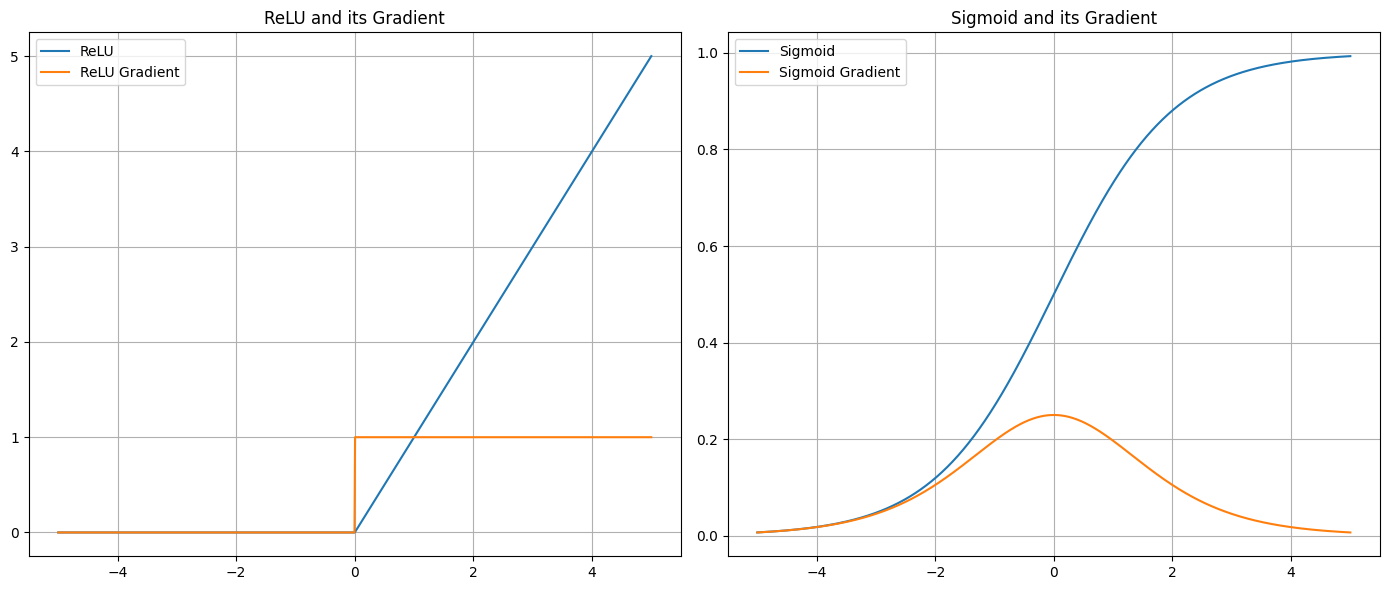

In [ ]:
visualize_gradients()

In [ ]:
def demonstrate_vanishing_gradient():
    # 심층 신경망에서의 기울기 소실 문제 시뮬레이션
    n_layers = 100  # 층의 수

    # 초기 그래디언트
    initial_gradient = torch.tensor(1.0)

    # 임의의 입력값 (양수는 ReLU가 그래디언트를 1로 유지)
    x_relu_positive = torch.tensor(0.5)
    # 임의의 입력값 (Sigmoid는 대부분의 경우 그래디언트가 0.25 미만)
    x_sigmoid = torch.tensor(0.0)  # Sigmoid의 그래디언트가 최대인 지점

    current_relu_grad = initial_gradient
    current_sigmoid_grad = initial_gradient

    relu_gradients = [current_relu_grad.item()]
    sigmoid_gradients = [current_sigmoid_grad.item()]

    for i in range(1, n_layers):
        # ReLU 그래디언트 전파
        current_relu_grad = CustomReLU.backward(x_relu_positive, current_relu_grad)
        # Sigmoid 그래디언트 전파
        current_sigmoid_grad = CustomSigmoid.backward(x_sigmoid, current_sigmoid_grad)

        relu_gradients.append(current_relu_grad.item())
        sigmoid_gradients.append(current_sigmoid_grad.item())

    # 시각화
    plt.figure(figsize=(10, 6))
    plt.semilogy(relu_gradients, label='ReLU Gradient (x > 0)')
    plt.semilogy(sigmoid_gradients, label='Sigmoid Gradient (x = 0)')
    plt.grid(True)
    plt.xlabel('Layer')
    plt.ylabel('Gradient Magnitude (log scale)')
    plt.title('Vanishing Gradient Problem Demonstration')
    plt.legend()
    plt.show()

    print(f"ReLU 그래디언트 (100층 후): {relu_gradients[-1]:.10f}")
    print(f"Sigmoid 그래디언트 (100층 후): {sigmoid_gradients[-1]:.10f}")

    # Sigmoid 추가 확인 - 극단적인 입력값에서
    x_extreme = torch.tensor(5.0)  # 매우 큰 양수
    extreme_sigmoid_grads = [initial_gradient.item()]
    current_grad = initial_gradient

    for i in range(1, n_layers):
        current_grad = CustomSigmoid.backward(x_extreme, current_grad)
        extreme_sigmoid_grads.append(current_grad.item())

    print(f"극단적인 입력(x=5)에서 Sigmoid 그래디언트 (100층 후): {extreme_sigmoid_grads[-1]:.10e}")


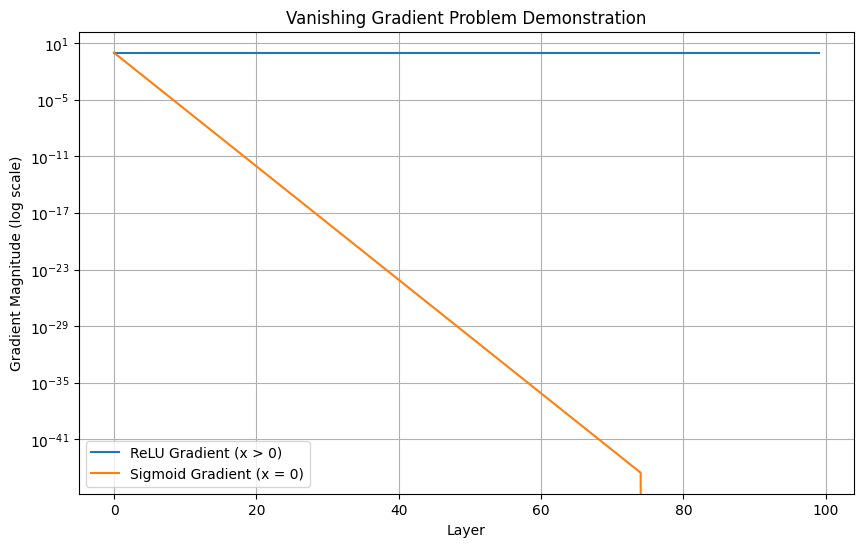

ReLU 그래디언트 (100층 후): 1.0000000000
Sigmoid 그래디언트 (100층 후): 0.0000000000
극단적인 입력(x=5)에서 Sigmoid 그래디언트 (100층 후): 0.0000000000e+00


In [ ]:
demonstrate_vanishing_gradient()